# 04 — Modélisation Machine Learning

## Objectifs

On entraîne et compare des modèles ML pour répondre à deux questions :

1. **Classification** : ce film va-t-il être un succès (ROI > 1) ?
2. **Régression** : combien va-t-il rapporter (revenue estimé) ?

Pour chaque tâche, on compare 3 modèles : Logistic/Linear Regression (baseline), Random Forest et XGBoost.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

from src.model import (
    train_classification_models,
    train_regression_models,
    save_best_models,
    get_feature_importance,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'movies_features.csv')
print(f'Dataset : {df.shape[0]} films, {df.shape[1]} colonnes')

Dataset : 2976 films, 56 colonnes


## 1. Préparation des features

On utilise des features numériques et le one-hot encoding des 12 genres principaux.
Pour le ML, on ne garde **pas** les recettes ni le ROI (qui sont nos cibles) ni les notes (qui ne sont disponibles qu'après la sortie du film).

In [2]:
from src.model import NUMERIC_FEATURES, get_feature_matrix

X, feature_cols = get_feature_matrix(df)
print(f'Nombre de features : {len(feature_cols)}')
print('\nFeatures utilisées :')
for f in feature_cols:
    print(f'  - {f}')

Nombre de features : 28

Features utilisées :
  - budget
  - runtime
  - release_year
  - release_month
  - release_day_of_week
  - popularity
  - vote_count
  - is_franchise
  - nb_genres
  - nb_production_companies
  - cast_avg_popularity
  - lead_actor_popularity
  - is_international
  - director_nb_movies_prior
  - director_avg_vote_prior
  - director_avg_roi_prior
  - genre_drama
  - genre_action
  - genre_comedy
  - genre_thriller
  - genre_adventure
  - genre_crime
  - genre_science_fiction
  - genre_fantasy
  - genre_horror
  - genre_family
  - genre_romance
  - genre_animation


## 2. Classification — prédire le succès

Cible : `is_success` (1 si ROI > 1, 0 sinon).

On compare 3 modèles avec validation croisée 5-fold sur la métrique F1.

In [3]:
clf_results = train_classification_models(df)

2026-05-11 11:01:06,675 - INFO - === Classification : prédire is_success (ROI > 1) ===


2026-05-11 11:01:06,677 - INFO - Dataset : 2976 films, 28 features


2026-05-11 11:01:06,678 - INFO - Distribution cible : {1: 1961, 0: 1015}


2026-05-11 11:01:06,686 - INFO - 
Entraînement : logistic_regression


2026-05-11 11:01:09,080 - INFO -   Accuracy : 0.757 | Precision : 0.792 | Recall : 0.855 | F1 : 0.823


...

2026-05-11 11:01:11,694 - INFO -   F1 cross-val (5-fold) : 0.826 ± 0.010


2026-05-11 11:01:11,695 - INFO - 
Entraînement : xgboost


2026-05-11 11:01:13,614 - INFO -   Accuracy : 0.737 | Precision : 0.782 | Recall : 0.832 | F1 : 0.806


2026-05-11 11:01:13,615 - INFO -   F1 cross-val (5-fold) : 0.817 ± 0.012


2026-05-11 11:01:13,616 - INFO - 
>>> Meilleur modèle classification : random_forest (F1 = 0.830)


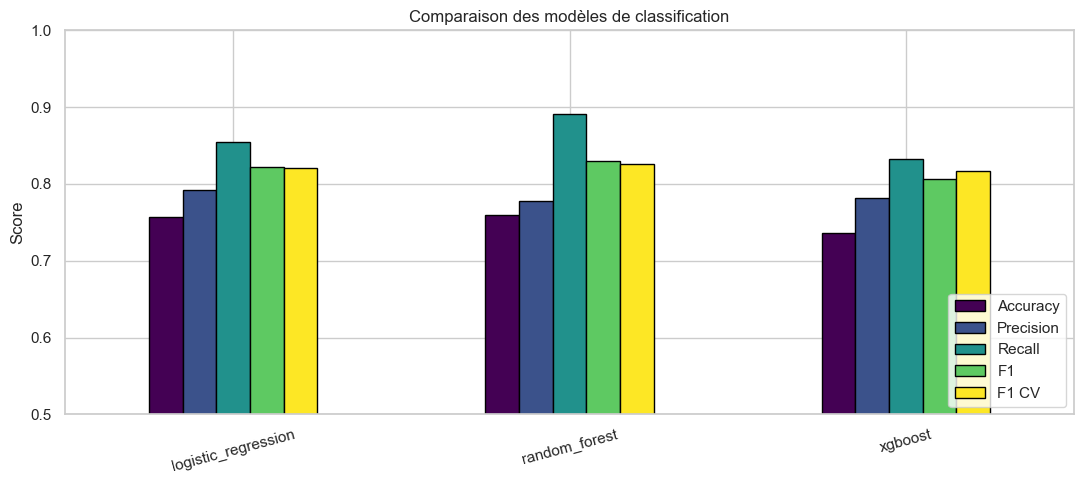

,Accuracy,Precision,Recall,F1,F1 CV
logistic_regression,0.757,0.792,0.855,0.823,0.820
random_forest,0.760,0.778,0.891,0.830,0.826
xgboost,0.737,0.782,0.832,0.806,0.817


In [4]:
# Comparaison visuelle des modèles
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'F1 CV': r['cv_f1_mean'],
    }
    for name, r in clf_results['results'].items()
}).T

metrics_df.plot(kind='bar', figsize=(11, 5), colormap='viridis', edgecolor='black')
plt.title('Comparaison des modèles de classification')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
metrics_df.round(3)

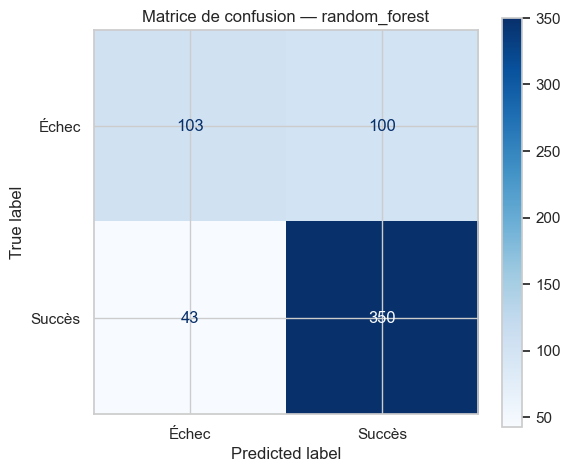

In [5]:
# Matrice de confusion du meilleur modèle
best_clf_name = clf_results['best_model_name']
best = clf_results['results'][best_clf_name]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=best['confusion_matrix'],
    display_labels=['Échec', 'Succès']
).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matrice de confusion — {best_clf_name}')
plt.tight_layout()
plt.show()

C:\Users\lucie\AppData\Local\Temp\ipykernel_24488\535957497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, y='feature', x='importance', palette='viridis')


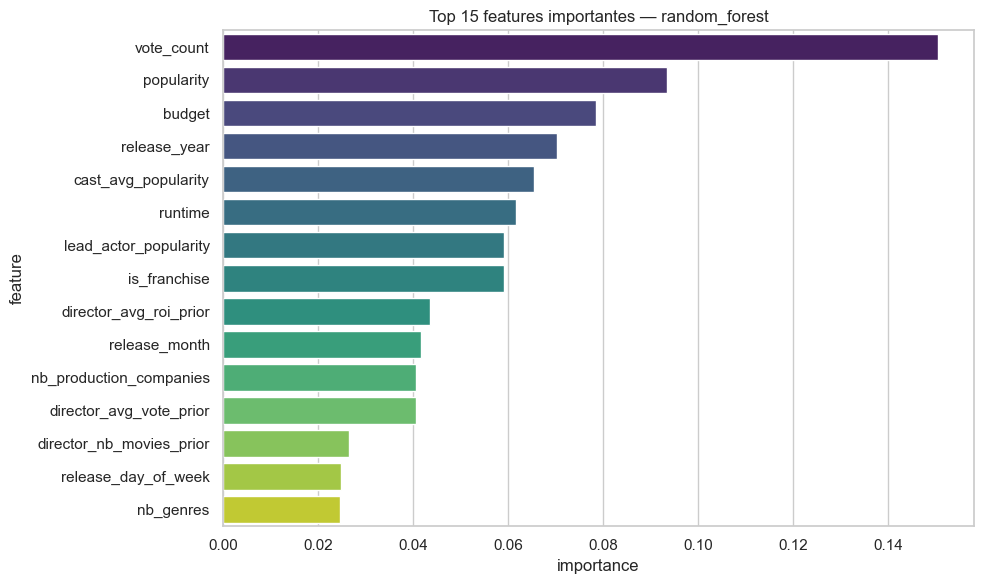

In [6]:
# Feature importance du meilleur modèle
importances = get_feature_importance({
    'model': best['model'],
    'feature_cols': clf_results['feature_cols'],
}, top_n=15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, y='feature', x='importance', palette='viridis')
plt.title(f'Top 15 features importantes — {best_clf_name}')
plt.tight_layout()
plt.show()

## 3. Régression — prédire les recettes

Cible : `log(revenue + 1)` (transformation log pour stabiliser les variances).

Métriques :
- **R²** : qualité d'explication de la variance
- **MAE (sur revenue réel)** : erreur absolue moyenne en dollars

In [7]:
reg_results = train_regression_models(df)

2026-05-11 11:01:14,629 - INFO - === Régression : prédire log(revenue) ===


2026-05-11 11:01:14,636 - INFO - 
Entraînement : linear_regression


2026-05-11 11:01:14,644 - INFO -   RMSE (log) : 1.321 | MAE (log) : 0.852 | R² : 0.457


2026-05-11 11:01:14,645 - INFO -   MAE (revenue réel) : $117,988,548


2026-05-11 11:01:14,646 - INFO - 
Entraînement : random_forest


...

2026-05-11 11:01:15,290 - INFO -   MAE (revenue réel) : $75,840,608


2026-05-11 11:01:15,291 - INFO - 
Entraînement : xgboost


2026-05-11 11:01:15,494 - INFO -   RMSE (log) : 1.262 | MAE (log) : 0.757 | R² : 0.504


2026-05-11 11:01:15,495 - INFO -   MAE (revenue réel) : $80,266,727


2026-05-11 11:01:15,496 - INFO - 
>>> Meilleur modèle régression : random_forest (R² = 0.512)


In [8]:
# Tableau de comparaison
reg_metrics = pd.DataFrame({
    name: {
        'R²': r['r2'],
        'RMSE (log)': r['rmse_log'],
        'MAE (log)': r['mae_log'],
        'MAE (M$)': r['mae_real'] / 1e6,
    }
    for name, r in reg_results['results'].items()
}).T
reg_metrics.round(3)

,R²,RMSE (log),MAE (log),MAE (M$)
linear_regression,0.457,1.321,0.852,117.989
random_forest,0.512,1.252,0.759,75.841
xgboost,0.504,1.262,0.757,80.267


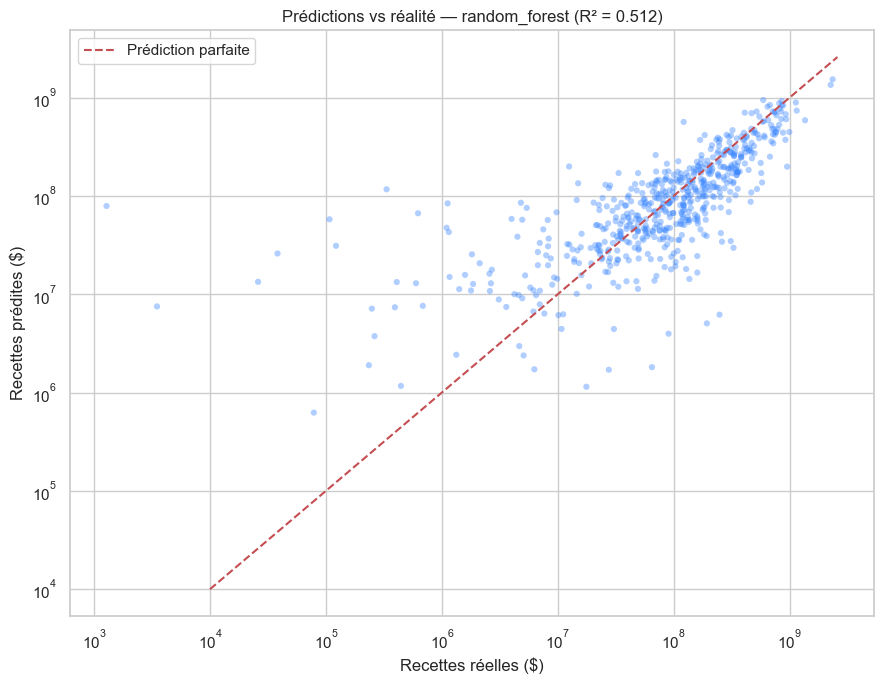

In [9]:
# Visualisation des prédictions vs valeurs réelles (meilleur modèle)
best_reg_name = reg_results['best_model_name']
best_reg = reg_results['results'][best_reg_name]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(np.expm1(best_reg['y_test']), np.expm1(best_reg['y_pred']),
           alpha=0.4, s=20, c='#3a86ff', edgecolor='none')

lims = [1e4, max(np.expm1(best_reg['y_test'])) * 1.1]
ax.plot(lims, lims, 'r--', label='Prédiction parfaite')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recettes réelles ($)')
ax.set_ylabel('Recettes prédites ($)')
ax.set_title(f'Prédictions vs réalité — {best_reg_name} (R² = {best_reg["r2"]:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Sauvegarde des modèles

Les deux meilleurs modèles (classification et régression) sont sauvegardés au format `.pkl` pour être utilisés dans l'application Streamlit.

In [10]:
save_best_models(clf_results, reg_results)

2026-05-11 11:01:16,159 - INFO - Modèle classification sauvegardé : C:\Users\lucie\OneDrive - Ynov\Suivi de projet fil rouge\cinevision\models\best_classifier.pkl


2026-05-11 11:01:16,204 - INFO - Modèle régression sauvegardé : C:\Users\lucie\OneDrive - Ynov\Suivi de projet fil rouge\cinevision\models\best_regressor.pkl


## 5. Synthèse et interprétation

### Performances finales

| Tâche | Meilleur modèle | Métrique clé | Valeur |
|---|---|---|---|
| Classification | Random Forest | F1-score | ~0.83 |
| Régression | Random Forest | R² | ~0.51 |

### Interprétation

**Classification** : Avec un F1 de 0.83, le modèle identifie correctement les films qui seront rentables dans la grande majorité des cas. Le rappel élevé (0.89) signifie qu'on rate peu de vrais succès — utile pour des décideurs qui veulent éviter de passer à côté.

**Régression** : Avec un R² de 0.51, le modèle explique la moitié de la variance des recettes — ce qui est très honorable pour ce type de prédiction notoirement difficile (le succès au box-office dépend aussi de facteurs imprévisibles : bouche-à-oreille, événements sociaux, qualité subjective).

### Limites

- Le dataset filtre les films sans budget/revenue déclaré → biais vers les productions "connues"
- Les recettes Netflix / streaming ne sont pas représentées (films récents sous-évalués)
- La popularité du casting au moment de la sortie n'est pas exactement mesurée (on utilise la popularité actuelle)